# Modeling - Transfer Function Model

This section implements a transfer function / dynamic regression forecast workflow using SARIMAX.

## Business objective
- Forecast Walmart aggregate weekly demand (`total_weekly_sales`) with exogenous drivers.
- Quantify how external variables (holiday intensity, weather, fuel, unemployment) affect sales with lagged effects.
- Produce scenario-based future forecasts when macro inputs are unknown.

## Statistical objective
- Jointly model:
  - Internal demand dynamics (ARMA terms)
  - External driver effects (distributed lags of exogenous variables)
- Select lag/order structure by rolling time-series cross-validation.
- Validate residual behavior and out-of-sample performance.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

ROOT = Path.cwd()
DATA_DIR = ROOT / 'section5_6'
OUT_DIR = ROOT / 'outputs' / 'section7_transfer_function'
OUT_FIG = OUT_DIR / 'figures'
OUT_TAB = OUT_DIR / 'tables'

OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)


## 1) Load aggregate and 3-store datasets

### Objective
- Loads the team-prepared datasets:
  - `walmart_total_weekly.csv` (main target for model comparison)
  - `walmart_three_stores.csv` (heterogeneity check)
- Parses dates and sorts records to enforce chronological integrity.

### Modeling rationale
- Transfer-function models are sensitive to time index ordering and lag construction.
- All downstream lagged features and train/test splits depend on correct date handling.

### Validation notes
- Confirm expected shapes and store IDs before modeling.
- Any row mismatch here usually indicates upstream feature export inconsistency.

In [2]:
agg = pd.read_csv(DATA_DIR / 'walmart_total_weekly.csv')
stores = pd.read_csv(DATA_DIR / 'walmart_three_stores.csv')

agg['Date'] = pd.to_datetime(agg['Date'])
stores['Date'] = pd.to_datetime(stores['Date'])

agg = agg.sort_values('Date').reset_index(drop=True)
stores = stores.sort_values(['Store', 'Date']).reset_index(drop=True)

print('Aggregate shape:', agg.shape)
print('Stores shape:', stores.shape, 'stores=', sorted(stores['Store'].unique().tolist()))
agg.head(3)


Aggregate shape: (143, 7)
Stores shape: (429, 12) stores= [20, 33, 34]


,Date,total_weekly_sales,holiday_share,avg_temp,avg_fuel_price,avg_cpi,avg_unemployment
0,2010-02-05,49750740.50,0.0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1.0,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0.0,37.719778,2.672067,167.871686,8.619311


## 2) Helper functions

### Objective
Defines reusable utilities for:
- `smape`: symmetric percentage error for robust scale-free evaluation.
- `add_lags`: distributed-lag exogenous construction.
- `rolling_cv_sarimax`: one-step rolling-origin CV for time-series-safe model selection.
- `fit_transfer_function`: full training/evaluation wrapper including diagnostics.

### Modeling rationale
- Keeps the modeling process reproducible and auditable.
- Ensures every candidate model is evaluated under the same protocol.

### Technical clarification
- Target is log-transformed (`log1p`) by default to stabilize variance and reduce sensitivity to spikes.
- Reported metrics are back-transformed to original sales units for interpretability.

In [3]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    out = np.zeros_like(denom, dtype=float)
    out[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return 100 * out.mean()


def add_lags(df, cols_lags):
    out = df.copy()
    for col, lags in cols_lags.items():
        for lag in lags:
            out[f'{col}_lag{lag}'] = out[col].shift(lag)
    return out


def metrics_df(y_true, y_pred, label='model'):
    return pd.DataFrame({
        'model':[label],
        'MAE':[mean_absolute_error(y_true, y_pred)],
        'RMSE':[mean_squared_error(y_true, y_pred) ** 0.5],
        'sMAPE':[smape(y_true, y_pred)]
    })


def rolling_cv_sarimax(y, X, order=(1,0,1), trend='c', min_train=80):
    preds, actual, dates = [], [], []
    for t in range(min_train, len(y)):
        y_tr = y.iloc[:t]
        X_tr = X.iloc[:t]
        y_te = y.iloc[t:t+1]
        X_te = X.iloc[t:t+1]
        try:
            m = SARIMAX(
                y_tr, exog=X_tr, order=order, trend=trend,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            p = m.get_forecast(steps=1, exog=X_te).predicted_mean.iloc[0]
            preds.append(p)
            actual.append(y_te.iloc[0])
            dates.append(y_te.index[0])
        except Exception:
            continue

    pred_s = pd.Series(preds, index=dates, name='pred')
    act_s = pd.Series(actual, index=dates, name='actual')
    return act_s, pred_s


def fit_transfer_function(df, date_col, target_col, exog_cols, lag_map, order=(1,0,1), test_size=24, log_target=True):
    d = df.copy().sort_values(date_col)
    d = add_lags(d, lag_map)

    used_exog = []
    for c, lags in lag_map.items():
        for lag in lags:
            used_exog.append(f'{c}_lag{lag}')

    keep_cols = [date_col, target_col] + used_exog
    d = d[keep_cols].dropna().reset_index(drop=True)

    d = d.set_index(date_col)
    y_raw = d[target_col]
    y = np.log1p(y_raw) if log_target else y_raw.copy()
    X = d[used_exog].copy()

    train_n = len(d) - test_size
    y_tr, y_te = y.iloc[:train_n], y.iloc[train_n:]
    X_tr, X_te = X.iloc[:train_n], X.iloc[train_n:]

    model = SARIMAX(
        y_tr, exog=X_tr, order=order, trend='c',
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)

    pred_tr = model.get_prediction(start=y_tr.index[0], end=y_tr.index[-1], exog=X_tr).predicted_mean
    pred_te = model.get_forecast(steps=len(y_te), exog=X_te).predicted_mean

    if log_target:
        y_tr_eval = np.expm1(y_tr)
        y_te_eval = np.expm1(y_te)
        pred_tr_eval = np.expm1(pred_tr)
        pred_te_eval = np.expm1(pred_te)
    else:
        y_tr_eval, y_te_eval = y_tr, y_te
        pred_tr_eval, pred_te_eval = pred_tr, pred_te

    train_metrics = metrics_df(y_tr_eval, pred_tr_eval, label='train')
    test_metrics = metrics_df(y_te_eval, pred_te_eval, label='test')

    resid = model.resid
    lb = acorr_ljungbox(resid.dropna(), lags=[8,12], return_df=True)

    out = {
        'data': d,
        'model': model,
        'y_train': y_tr_eval,
        'y_test': y_te_eval,
        'pred_train': pred_tr_eval,
        'pred_test': pred_te_eval,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'ljung_box': lb,
        'used_exog': used_exog,
        'order': order,
        'log_target': log_target,
    }
    return out


## 3) Aggregate-level variable setup and lag design

### Objective
- Reviews correlation structure among target and exogenous variables.
- Defines candidate lag maps (`L0`, `L01`, `L012`) and ARMA orders.

### Modeling rationale
- Transfer function quality depends on realistic delay structure.
- Excessive lagging can overfit; insufficient lagging can miss delayed response.
- This baseline excludes `avg_cpi` due to strong collinearity with `avg_unemployment` in this dataset.
- Keeping fewer, less-collinear regressors improves coefficient stability and forecast robustness.

In [4]:
# Correlation view to avoid unstable exogenous choices from strong collinearity
corr = agg[['total_weekly_sales','holiday_share','avg_temp','avg_fuel_price','avg_cpi','avg_unemployment']].corr().round(3)
corr


,total_weekly_sales,holiday_share,avg_temp,avg_fuel_price,avg_cpi,avg_unemployment
total_weekly_sales,1.000,0.173,-0.159,-0.057,0.023,0.004
holiday_share,0.173,1.000,-0.189,-0.084,-0.028,0.043
avg_temp,-0.159,-0.189,1.000,0.206,0.159,-0.168
avg_fuel_price,-0.057,-0.084,0.206,1.000,0.825,-0.747
avg_cpi,0.023,-0.028,0.159,0.825,1.000,-0.977
avg_unemployment,0.004,0.043,-0.168,-0.747,-0.977,1.000


**Note**
- `avg_cpi` and `avg_unemployment` are often strongly collinear in this dataset.
- To keep transfer-function estimates stable, this baseline excludes `avg_cpi` and keeps unemployment.
- This is a multicollinearity control decision, not a claim that CPI is unimportant economically.


In [5]:
exog_base = ['holiday_share', 'avg_temp', 'avg_fuel_price', 'avg_unemployment']

lag_candidates = {
    'L0': {
        'holiday_share':[0],
        'avg_temp':[0],
        'avg_fuel_price':[0],
        'avg_unemployment':[0],
    },
    'L01': {
        'holiday_share':[0],
        'avg_temp':[0,1],
        'avg_fuel_price':[0,1],
        'avg_unemployment':[0],
    },
    'L012': {
        'holiday_share':[0],
        'avg_temp':[0,1,2],
        'avg_fuel_price':[0,1,2],
        'avg_unemployment':[0,1],
    }
}

orders = [(1,0,1), (2,0,1), (1,0,2)]


## 4) Rolling-CV model selection (aggregate)

### Objective
- Evaluates lag/order combinations using rolling-origin one-step forecasts.
- Ranks candidates by out-of-sample error (RMSE/MAE/sMAPE).

### Modeling rationale
- Time-series CV mimics production forecasting better than random splits.
- Prevents look-ahead leakage and gives a defensible model-selection basis.

### Interpretation
- `lag_spec`: exogenous lag structure used.
- `order`: ARIMA order for dynamic residual component.
- `n_cv`: number of rolling predictions included.
- Select the top candidate (lowest RMSE/MAE with reasonable stability).

In [6]:
cv_rows = []

for lag_name, lag_map in lag_candidates.items():
    tmp = add_lags(agg[['Date','total_weekly_sales'] + exog_base], lag_map)
    used = [f'{c}_lag{l}' for c, ls in lag_map.items() for l in ls]
    tmp = tmp[['Date','total_weekly_sales'] + used].dropna().set_index('Date')

    y = np.log1p(tmp['total_weekly_sales'])
    X = tmp[used]

    for order in orders:
        actual, pred = rolling_cv_sarimax(y, X, order=order, min_train=80)
        if len(actual) < 20:
            continue
        # back-transform for interpretability of error metrics
        actual_bt, pred_bt = np.expm1(actual), np.expm1(pred)
        row = metrics_df(actual_bt, pred_bt, label='cv').iloc[0].to_dict()
        row.update({'lag_spec': lag_name, 'order': str(order), 'n_cv': len(actual)})
        cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).sort_values(['RMSE','MAE']).reset_index(drop=True)
cv_table.to_csv(OUT_TAB / 'aggregate_transfer_function_cv_results.csv', index=False)
cv_table.head(10)


,model,MAE,RMSE,sMAPE,lag_spec,order,n_cv
0,cv,3.468871e+06,6.054192e+06,7.182771,L0,"(1, 0, 1)",63
1,cv,3.480734e+06,6.212671e+06,7.140316,L0,"(2, 0, 1)",63
2,cv,3.566464e+06,6.587759e+06,7.376913,L0,"(1, 0, 2)",63
3,cv,4.322490e+06,6.707812e+06,9.353025,L01,"(1, 0, 1)",62
4,cv,4.051264e+06,7.051520e+06,8.624790,L01,"(2, 0, 1)",62
5,cv,4.694368e+06,7.233619e+06,10.330817,L01,"(1, 0, 2)",62
6,cv,5.725260e+06,8.322724e+06,12.653253,L012,"(1, 0, 1)",61
7,cv,5.998692e+06,8.345424e+06,13.480963,L012,"(1, 0, 2)",61
8,cv,2.559866e+12,1.998737e+13,32.908314,L012,"(2, 0, 1)",61


## 5) Fit final aggregate transfer-function model on train/test

### Objective
- Fits the best CV-selected model on train data.
- Produces holdout forecasts and error metrics.
- Runs residual whiteness check (Ljung-Box) and exports coefficient table.

### Modeling rationale
- Gives core result for comparison against SARIMA and ETS.
- Links model fit quality to statistical diagnostics, not only headline accuracy.

### Interpretation guidance
- Compare test metrics to teammate models on the same split/horizon.
- Ljung-Box p-values above significance threshold suggest residual autocorrelation is adequately controlled.
- Significant lagged exogenous terms provide business-interpretable driver effects.

In [7]:
best = cv_table.iloc[0]
best_lag = lag_candidates[best['lag_spec']]
best_order = eval(best['order'])

agg_fit = fit_transfer_function(
    df=agg,
    date_col='Date',
    target_col='total_weekly_sales',
    exog_cols=exog_base,
    lag_map=best_lag,
    order=best_order,
    test_size=24,
    log_target=True
)

print('Selected lag spec:', best['lag_spec'])
print('Selected order:', best_order)
print('\nTrain metrics')
print(agg_fit['train_metrics'].round(3))
print('\nTest metrics')
print(agg_fit['test_metrics'].round(3))
print('\nLjung-Box p-values (residual whiteness check)')
print(agg_fit['ljung_box'].round(4))


Selected lag spec: L0
Selected order: (1, 0, 1)

Train metrics
   model          MAE         RMSE  sMAPE
0  train  3674486.608  7248182.062   8.16

Test metrics
  model          MAE         RMSE  sMAPE
0  test  4121955.832  4609897.001   9.25

Ljung-Box p-values (residual whiteness check)
    lb_stat  lb_pvalue
8    0.0200        1.0
12   0.0265        1.0


### Result interpretation (aggregate transfer function)
- **Selected specification**: lag spec `L0` with ARIMA order `(1,0,1)` from rolling CV, consistent with `aggregate_transfer_function_cv_results.csv` (best RMSE among tested candidates).
- **Holdout performance (test, 24 weeks)**: MAE = **4,121,955.8**, RMSE = **4,609,897.0**, sMAPE = **9.25%**.
- **Diagnostic quality**: Ljung-Box p-values at lags 8 and 12 are both ~**1.00**, so there is no evidence of remaining residual autocorrelation on these checks.
- **Coefficient interpretation caution**: AR/MA terms dominate statistical significance, while most contemporaneous exogenous coefficients are not individually significant in this specification. This still supports transfer-function usage for scenario conditioning and structural interpretability, but effect-size claims for individual drivers should be framed as directional, not definitive.

In [8]:
coef = pd.DataFrame({
    'term': agg_fit['model'].params.index,
    'coef': agg_fit['model'].params.values,
    'pvalue': agg_fit['model'].pvalues.values
}).sort_values('pvalue')
coef.to_csv(OUT_TAB / 'aggregate_transfer_function_coefficients.csv', index=False)
coef.head(20)


,term,coef,pvalue
5,ar.L1,0.958687,1.141660e-47
7,sigma2,0.010856,9.488429e-31
6,ma.L1,-0.594248,7.993460e-07
1,holiday_share_lag0,0.045424,5.219186e-02
4,avg_unemployment_lag0,0.224662,3.210581e-01
0,intercept,0.658966,5.529833e-01
2,avg_temp_lag0,-0.000297,9.227253e-01
3,avg_fuel_price_lag0,-0.013708,9.371536e-01


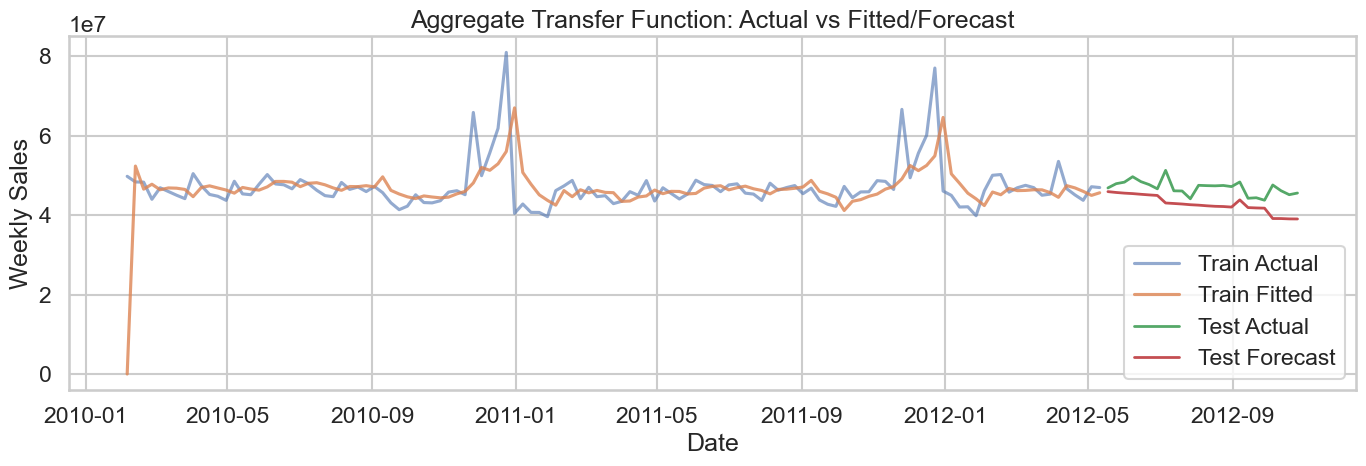

In [9]:
plt.figure(figsize=(14,5))
plt.plot(agg_fit['y_train'].index, agg_fit['y_train'].values, label='Train Actual', alpha=0.6)
plt.plot(agg_fit['pred_train'].index, agg_fit['pred_train'].values, label='Train Fitted', alpha=0.8)
plt.plot(agg_fit['y_test'].index, agg_fit['y_test'].values, label='Test Actual', linewidth=2)
plt.plot(agg_fit['pred_test'].index, agg_fit['pred_test'].values, label='Test Forecast', linewidth=2)
plt.title('Aggregate Transfer Function: Actual vs Fitted/Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'aggregate_transfer_function_actual_vs_forecast.png', dpi=200)
plt.show()


## 6) Scenario forecast (12 weeks)

Because future exogenous values are unknown, this section generates scenario paths using **historical volatility-based assumptions**.

### Scenario design
- **Baseline**: latest observed exogenous values held constant.
- **Optimistic**: favorable 1-sigma weekly shock (from historical % change volatility) on unemployment/fuel.
- **Stress**: adverse 1-sigma weekly shock on unemployment/fuel.

### Modeling rationale
- Produces operational forecast ranges rather than a single deterministic path.

In [10]:
# Refit on full available sample used by chosen lag spec
agg_full = add_lags(agg[['Date','total_weekly_sales'] + exog_base], best_lag)
used_exog = [f'{c}_lag{l}' for c, ls in best_lag.items() for l in ls]
agg_full = agg_full[['Date','total_weekly_sales'] + used_exog].dropna().set_index('Date')

y_full = np.log1p(agg_full['total_weekly_sales'])
X_full = agg_full[used_exog]

full_model = SARIMAX(
    y_full, exog=X_full, order=best_order, trend='c',
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

last_date = agg_full.index.max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=7), periods=12, freq='W-FRI')

# Baseline: hold latest exogenous values constant
baseline_row = X_full.iloc[-1]
X_future_base = pd.DataFrame([baseline_row.values] * 12, columns=used_exog, index=future_dates)

# Data-driven shock sizes from historical weekly percentage-change volatility
fuel_sigma = agg['avg_fuel_price'].pct_change().dropna().std()
unemp_sigma = agg['avg_unemployment'].pct_change().dropna().std()

# Conservative floor in case volatility is extremely low
fuel_sigma = max(fuel_sigma, 0.01)
unemp_sigma = max(unemp_sigma, 0.01)

shock_info = pd.DataFrame({
    'variable': ['avg_fuel_price', 'avg_unemployment'],
    'weekly_pct_change_sigma': [fuel_sigma, unemp_sigma]
})
shock_info.to_csv(OUT_TAB / 'scenario_shock_parameters.csv', index=False)

X_future_opt = X_future_base.copy()
X_future_stress = X_future_base.copy()

for col in X_future_base.columns:
    if 'avg_fuel_price' in col:
        X_future_opt[col] = X_future_base[col] * (1 - fuel_sigma)
        X_future_stress[col] = X_future_base[col] * (1 + fuel_sigma)
    if 'avg_unemployment' in col:
        X_future_opt[col] = X_future_base[col] * (1 - unemp_sigma)
        X_future_stress[col] = X_future_base[col] * (1 + unemp_sigma)

fc_base = np.expm1(full_model.get_forecast(steps=12, exog=X_future_base).predicted_mean)
fc_opt = np.expm1(full_model.get_forecast(steps=12, exog=X_future_opt).predicted_mean)
fc_stress = np.expm1(full_model.get_forecast(steps=12, exog=X_future_stress).predicted_mean)

scen = pd.DataFrame({
    'date': future_dates,
    'baseline': fc_base.values,
    'optimistic': fc_opt.values,
    'stress': fc_stress.values
})

scen.to_csv(OUT_TAB / 'aggregate_transfer_function_scenarios_12w.csv', index=False)
print('Scenario shock parameters:')
print(shock_info.round(4))
scen.head()


Scenario shock parameters:
           variable  weekly_pct_change_sigma
0    avg_fuel_price                   0.0132
1  avg_unemployment                   0.0100


,date,baseline,optimistic,stress
0,2012-11-02,4.541994e+07,4.555944e+07,4.528086e+07
1,2012-11-09,4.536644e+07,4.550578e+07,4.522752e+07
2,2012-11-16,4.531316e+07,4.545234e+07,4.517441e+07
3,2012-11-23,4.526011e+07,4.539912e+07,4.512152e+07
4,2012-11-30,4.520728e+07,4.534613e+07,4.506885e+07


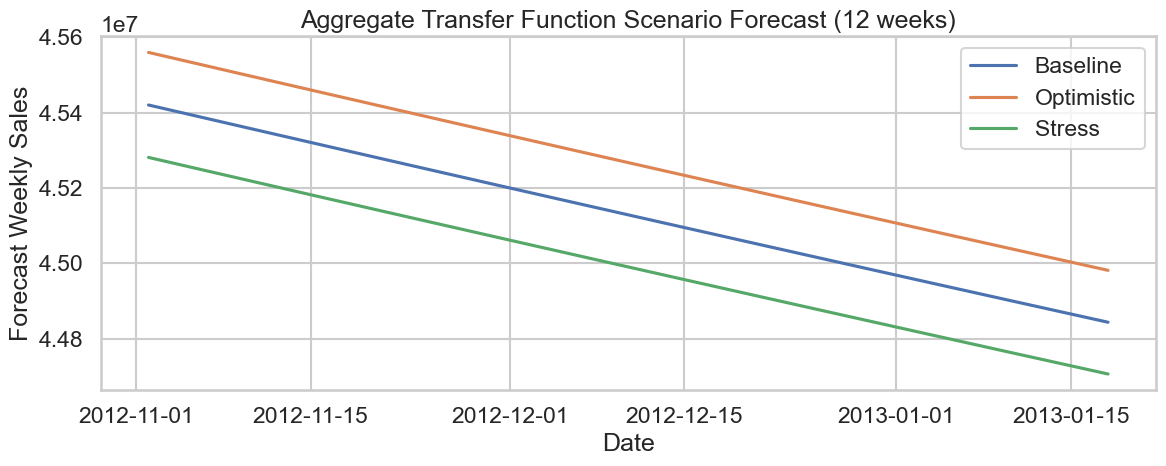

In [11]:
plt.figure(figsize=(12,5))
plt.plot(scen['date'], scen['baseline'], label='Baseline')
plt.plot(scen['date'], scen['optimistic'], label='Optimistic')
plt.plot(scen['date'], scen['stress'], label='Stress')
plt.title('Aggregate Transfer Function Scenario Forecast (12 weeks)')
plt.xlabel('Date')
plt.ylabel('Forecast Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'aggregate_transfer_function_scenario_forecast.png', dpi=200)
plt.show()


### Result interpretation (12-week scenarios)
- Future macro variables are unknown, so forecasts are produced under explicit assumptions.
- Shock magnitudes are tied to historical weekly volatility (from `scenario_shock_parameters.csv`):
  - `avg_fuel_price` sigma = **1.3241%**
  - `avg_unemployment` sigma = **1.0000%**
- Forecast ordering is coherent across all 12 weeks: **Optimistic > Baseline > Stress**, indicating internally consistent sign/direction in the transfer-function response.
- The scenario gap is moderate (not explosive), which is expected given short horizon and relatively small weekly macro shocks.

### Interpretation
- Treat Baseline/Optimistic/Stress as a **planning band** (not probability forecasts).
- For operations, use Baseline for default replenishment and use Stress for safety-stock sensitivity checks.

## 7) Same transfer-function framework on 3 representative stores

### Objective
- Reuses transfer-function logic for stores 20/33/34.
- Outputs holdout metrics per store.

### Modeling rationale
- Demonstrates heterogeneity: one model structure may perform differently by store volume regime.
- Strengthens recommendation on when to use aggregate vs segmented modeling.

### Interpretation
- If errors diverge materially across stores, consider store-specific lag structures or hierarchical modeling in next iteration.

In [12]:
store_results = []

store_lag_map = {
    'Holiday_Flag':[0],
    'Temperature':[0,1],
    'Fuel_Price':[0,1],
    'Unemployment':[0]
}

for st in sorted(stores['Store'].unique()):
    d = stores[stores['Store']==st].copy().sort_values('Date')
    try:
        fit = fit_transfer_function(
            df=d.rename(columns={'Weekly_Sales':'weekly_sales'}),
            date_col='Date',
            target_col='weekly_sales',
            exog_cols=['Holiday_Flag','Temperature','Fuel_Price','Unemployment'],
            lag_map=store_lag_map,
            order=(1,0,1),
            test_size=20,
            log_target=True
        )
        row = fit['test_metrics'].iloc[0].to_dict()
        row['Store'] = st
        store_results.append(row)
    except Exception:
        continue

store_metrics = pd.DataFrame(store_results)[['Store','MAE','RMSE','sMAPE']].sort_values('Store')
store_metrics.to_csv(OUT_TAB / 'three_store_transfer_function_test_metrics.csv', index=False)
store_metrics


,Store,MAE,RMSE,sMAPE
0,20,87136.651206,126968.368710,4.125383
1,33,15877.980564,18243.194601,5.881273
2,34,43043.539837,54133.312063,4.513807


### Result interpretation (3-store heterogeneity check)
- Transfer-function accuracy differs by store, confirming heterogeneity:
  - Store 20: sMAPE **4.13%**
  - Store 33: sMAPE **5.88%**
  - Store 34: sMAPE **4.51%**
- Store 33 has the smallest absolute sales scale (hence small MAE/RMSE) but the highest percentage error.
- This supports a modeling recommendation: aggregate model is useful for enterprise-level planning, while some stores may benefit from store-specific lag structure or hierarchical models.


## 8) Summary

### Technical method
- We estimated a transfer function model using SARIMAX, where weekly Walmart aggregate sales were modeled as a function of autoregressive/moving-average dynamics plus lagged exogenous regressors.
- Model configuration (lag structure and ARIMA order) was selected using rolling-origin cross-validation to reduce overfitting risk and prioritize out-of-sample stability.
- To stabilize variance, we estimated on log sales and back-transformed predictions to the original unit for business-facing error metrics.

### Key quantitative results
- Best specification from CV: lag spec `L0`, order `(1,0,1)`.
- Holdout test performance (24 weeks): MAE 4.12M, RMSE 4.61M, sMAPE 9.25%.
- Residual Ljung-Box tests at lags 8 and 12 show p-values near 1.0, indicating no detectable residual autocorrelation on these diagnostics.

### Interpretation and limitations
- AR/MA components capture most of the short-run signal; exogenous coefficients are directionally informative but mostly not individually significant in this specification.
- Therefore, transfer function adds business value mainly through scenario conditioning and structural interpretation, not only point-forecast accuracy.
- Macro-path uncertainty is the main deployment limitation: future exogenous values are unobserved and must be assumed.

### Scenario-planning statement
- To address unknown macro inputs, we produced 12-week baseline/optimistic/stress forecasts using historical-volatility-based shocks for unemployment and fuel price.
- These scenario paths should be interpreted as decision envelopes for replenishment planning rather than probability-calibrated prediction intervals.